# Exchangeable vs. total Cs137 ratio

> Prediction of exCs137/totalCs137 using Fukushima/J-REI data

In [ ]:
from pathlib import Path
import numpy as np
from fastcore.all import *
from soilspecdl.dataloader import get_fuku_cs137, get_spectral_dls, get_pre_splitter
from soilspecdl.transforms import StandardizeSpectrum
from soilspecdl.models import cnt_params

In [ ]:
from fastai.vision.all import *
from fastai.callback.hook import ActivationStats
from fastai.learner import Learner
from fastai.callback.schedule import lr_find
from fastai.losses import MSELossFlat
from fastai.metrics import R2Score
from fastai.callback.hook import ActivationStats
from functools import partial
import torch
from torch.nn import (AvgPool1d, LeakyReLU,
                        AdaptiveAvgPool1d, Sequential,
                        Dropout, Linear)

from fastai.layers import ConvLayer
from typing import Callable


## Data loading

In [ ]:
data_fuku = get_fuku_cs137(Path('../../_data/'))
wns = data_fuku['wns']
id_train, X_train, y_train = data_fuku['train'].values()
id_test, X_test, y_test = data_fuku['test'].values()

len(X_train), len(X_test), len(wns)

(1194, 398, 657)

In [ ]:
X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
splitter = get_pre_splitter(n_train=len(X_train))

(array([  3.,   5.,  15.,  48., 114., 255., 307., 395., 354.,  96.]),
 array([-2.92081875, -2.68932675, -2.45783474, -2.22634274, -1.99485073,
        -1.76335873, -1.53186672, -1.30037471, -1.06888271, -0.8373907 ,
        -0.6058987 ]),
 <BarContainer object of 10 artists>)

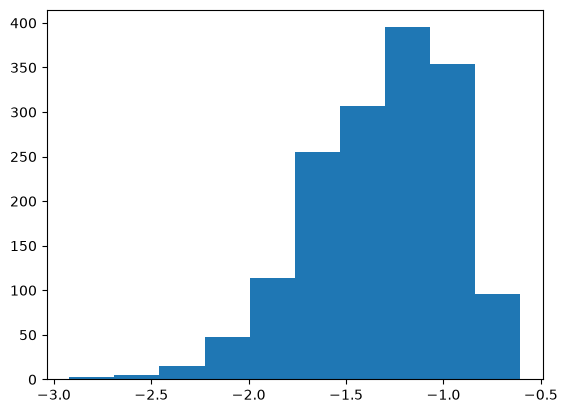

In [ ]:
plt.hist(y_all)

In [ ]:
np.min(y_all), np.max(y_all), np.mean(y_all), np.median(y_all)

(np.float64(-2.9208187539523753),
 np.float64(-0.6058986979599553),
 np.float64(-1.3219556704707955),
 np.float64(-1.2700257143004443))

In [ ]:
dls, test_idx = get_spectral_dls(
    X_all, y_all, 
    wns, 
    splitter=get_pre_splitter(n_train=len(X_train)), 
    batch_tfms=[StandardizeSpectrum()])

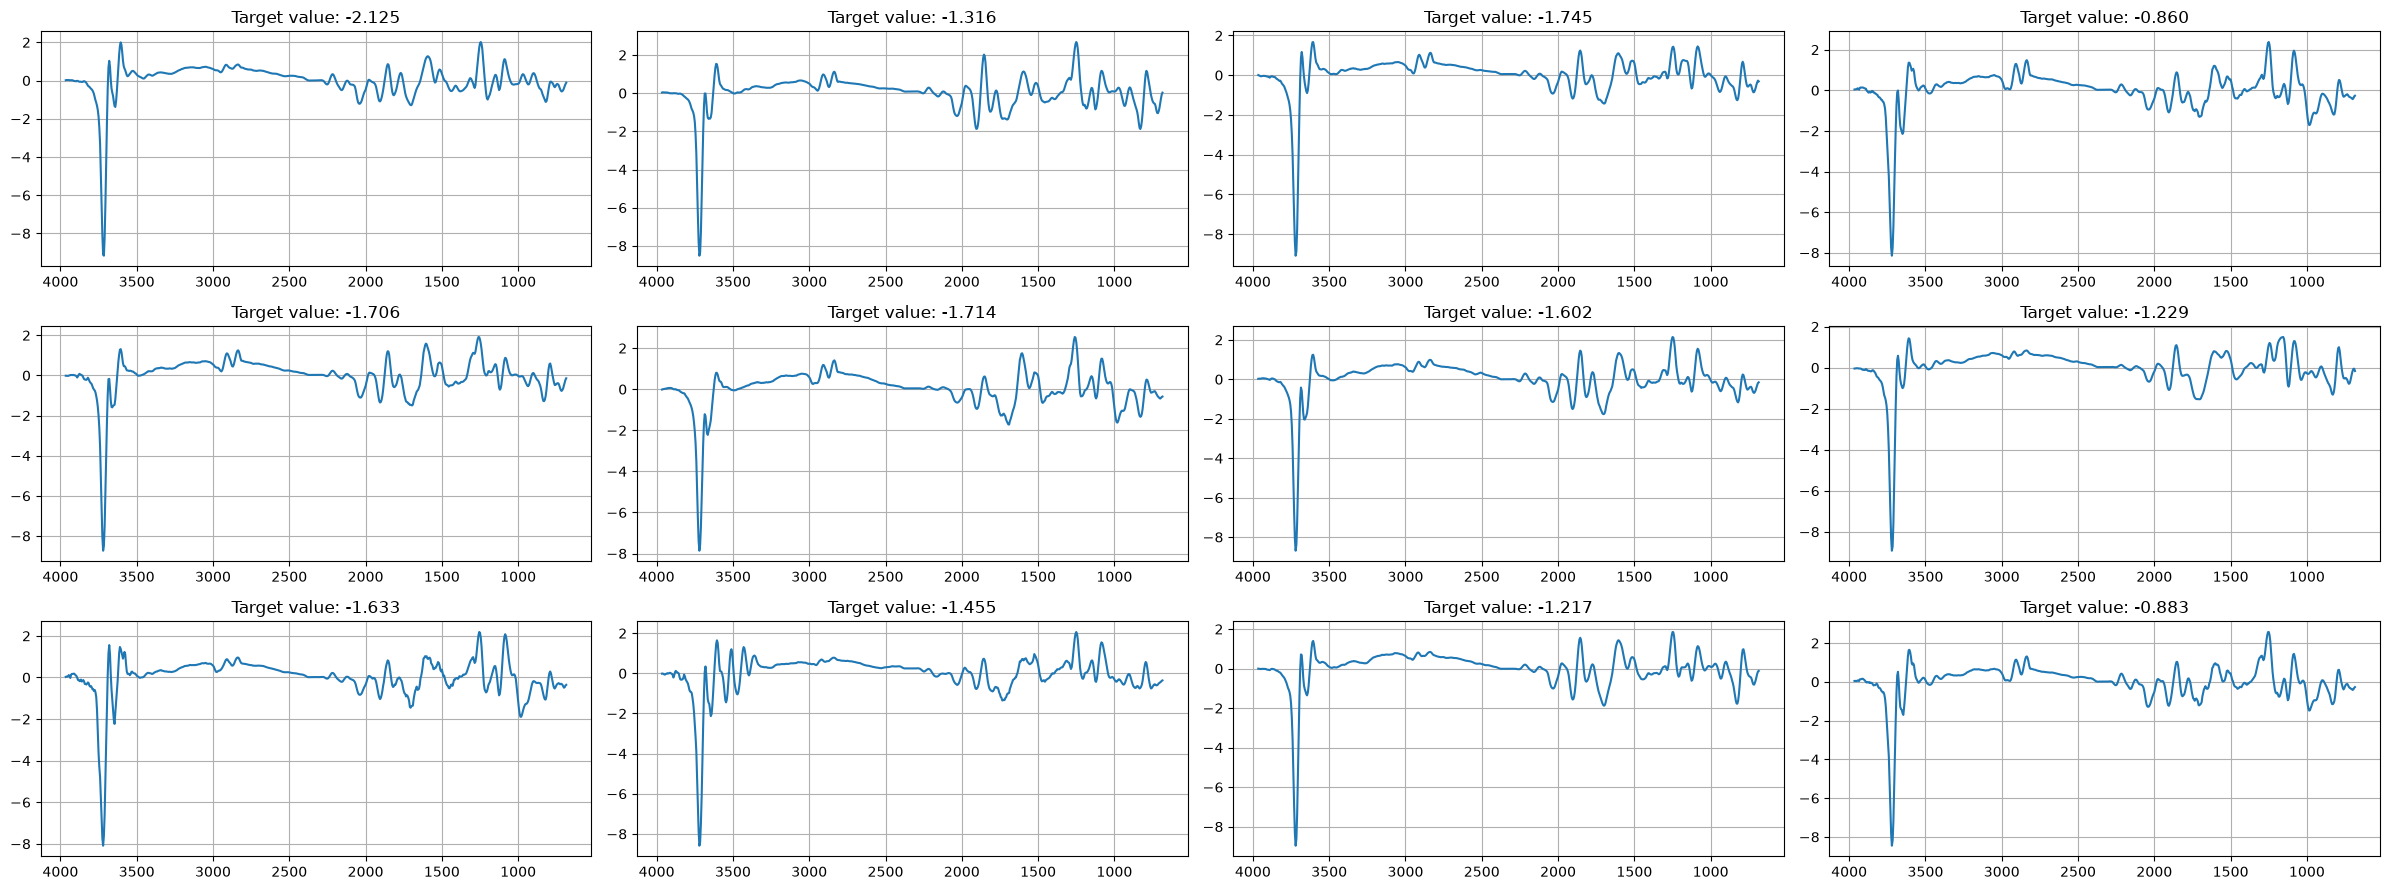

In [ ]:
dls.show_batch(max_n=12, ncols=4)

## Modeling

### Design notes: architecture and normalization (from initial exploration)

**Why not `MirzaiCNN` as-is.** `MirzaiCNN` (in `00_models.ipynb`, from Albinet et al. 2022) was tuned for 1701 wavenumbers: 5 `ConvBlock`s (`ConvLayer` + `AvgPool1d(3)`) reduce that to 7 spatial positions before the final `AdaptiveAvgPool1d(1)`. Fukushima's spectra have only 657 wavenumbers (resolution 5), so the same schedule would collapse to under 3 positions well before the end of the feature extractor -- too aggressive for this input length. `SimpleCNN` was built as a smaller architecture sized for 657 wavenumbers, not a drop-in replacement.

**Final `SimpleCNN` shape (below).** Six `ConvBlock`s, channels doubling 16 -> 32 -> 64 -> 128 -> 256 -> 512, each halving the wavenumber dimension (`AvgPool1d(2)`), taking it from 657 down to ~10 before the adaptive pool; the head is dropout then a single `Linear(512, 1)`. The guiding principle: push the wavenumber dimension down gradually while the channel dimension grows, so that by the time `AdaptiveAvgPool1d(1)` collapses the spatial axis to one value, that axis is already small (single digits) and each channel represents a broad, spectrum-wide concept rather than a specific location -- collapsing it too early (an earlier 2-layer draft only reached 164) risks losing which part of the spectrum a feature came from. The channel-doubling/spatial-halving pattern is intentionally similar to a discrete wavelet transform's multiresolution decomposition, with the conv layer learning the "wavelet" and pooling acting as the downsampler, except only the pooled "approximation" branch is carried forward at each scale. A single linear head was chosen deliberately over a deeper one: with only ~1,194 training samples, a 512-parameter weight matrix is already a tight fit, and the target (a bounded exchangeable/total Cs137 ratio) doesn't obviously need a more complex head -- add depth only if validation loss plateaus above what the feature extractor can supply.

**Normalization: `InstanceNorm1d` over `BatchNorm1d`.** `BatchNorm` computes one mean/std per channel pooled across the entire batch and the whole spectrum, mixing statistics across samples. That risks washing out real, structured variation between samples (soil type, moisture) that the model should keep. The domain's own preprocessing, SNV, standardizes each spectrum row-wise -- per sample, across wavenumbers -- which is structurally identical to Instance Normalization applied to the raw single-channel input. Extending that to the network's intermediate feature maps means `InstanceNorm1d(C)`: each of the C channels gets its own mean/std per sample, independent of the rest of the batch, consistent with SNV's own logic. Switching costs nothing in parameters: both `BatchNorm1d(C)` and `InstanceNorm1d(C)` have exactly `2C` learnable parameters (gamma, beta); only how the statistics are computed differs. `fastai`'s `ConvLayer` supports this directly via `norm_type=NormType.Instance`, which is what the current architecture uses throughout.

**Interpretability.** Channel activations ("a peak in channel 3", "a valley in channel 7") describe learned, task-driven feature-map patterns, not literal absorbance peaks in the raw spectrum, and because channels interact non-linearly there's no clean one-to-one mapping back to specific chemistry. `ActivationStats`, feature visualization, and per-channel probing against known soil properties are the standard ways to look inside, but the working stance is that interpretability is a bonus, not a requirement, as long as the model predicts well and is validated properly.

In [ ]:
class ConvBlock(Module):
    def __init__(self, ni, nf, pool_sz=2):
        store_attr()
        self.conv = ConvLayer(ni, nf, ks=3, norm_type=NormType.Instance, ndim=1)
        self.pool = AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FeatureExtractor(Module):
    def __init__(self, nfs=[16,32,64,128,256,512], pool_sz=2):
        store_attr()
        self.layers = Sequential(*[ConvBlock(nfs[i-1] if i else 1, nfs[i], pool_sz=pool_sz) for i in range(len(nfs))])
        self.pool = AdaptiveAvgPool1d(1)
    def forward(self, x): return self.pool(self.layers(x)).squeeze(-1)

class SimpleCNN(Module):
    def __init__(self, dropout=0.4):
        store_attr()
        self.features = FeatureExtractor()
        self.head = Sequential(Dropout(dropout), Linear(512, 1))
    def forward(self, x): return self.head(self.features(x)).squeeze(-1)

In [ ]:
learn = Learner(dls, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score())

In [ ]:
learn.model

SimpleCNN(
  (features): FeatureExtractor(
    (layers): Sequential(
      (0): ConvBlock(
        (conv): ConvLayer(
          (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): InstanceNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
          (2): ReLU()
        )
        (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
      )
      (1): ConvBlock(
        (conv): ConvLayer(
          (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): InstanceNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
          (2): ReLU()
        )
        (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
      )
      (2): ConvBlock(
        (conv): ConvLayer(
          (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): InstanceNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True,

In [ ]:
cnt_params(learn.model)

features.layers.0.conv.0.weight: 48 parameters
features.layers.0.conv.1.weight: 16 parameters
features.layers.0.conv.1.bias: 16 parameters
features.layers.1.conv.0.weight: 1,536 parameters
features.layers.1.conv.1.weight: 32 parameters
features.layers.1.conv.1.bias: 32 parameters
features.layers.2.conv.0.weight: 6,144 parameters
features.layers.2.conv.1.weight: 64 parameters
features.layers.2.conv.1.bias: 64 parameters
features.layers.3.conv.0.weight: 24,576 parameters
features.layers.3.conv.1.weight: 128 parameters
features.layers.3.conv.1.bias: 128 parameters
features.layers.4.conv.0.weight: 98,304 parameters
features.layers.4.conv.1.weight: 256 parameters
features.layers.4.conv.1.bias: 256 parameters
features.layers.5.conv.0.weight: 393,216 parameters
features.layers.5.conv.1.weight: 512 parameters
features.layers.5.conv.1.bias: 512 parameters
head.1.weight: 512 parameters
head.1.bias: 1 parameters

Total: 526,353 parameters


<div></div>

SuggestedLRs(valley=0.0014454397605732083)

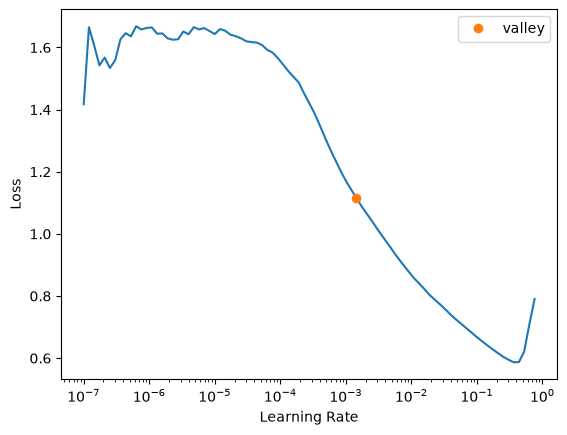

In [ ]:
learn.lr_find()

In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)

In [ ]:
import fastprogress.core
get_ipython().__class__.__name__, fastprogress.core.IN_NOTEBOOK

('ZMQInteractiveShell', True)

In [ ]:
learn.fit_one_cycle(30, lr_max=2e-3)

epoch,train_loss,valid_loss,r2_score,time
0,0.100601,0.062588,0.508863,00:01
1,0.090337,0.052758,0.586001,00:01
2,0.085177,0.048189,0.621858,00:01
3,0.083948,0.052932,0.584640,00:01
4,0.086264,0.061188,0.519847,00:01
5,0.086016,0.053082,0.583457,00:01
6,0.081935,0.053821,0.577660,00:01
7,0.080428,0.048700,0.617848,00:01
8,0.079829,0.058967,0.537279,00:01
9,0.077944,0.051348,0.597065,00:01


In [ ]:
def layer_names(modules):
      names, block = [], 0
      for m in modules:
          t = type(m).__name__
          if t == 'Conv1d': block += 1
          names.append(f"Head · {t}" if t == 'Linear' else f"Block {block} · {t}")
      return names

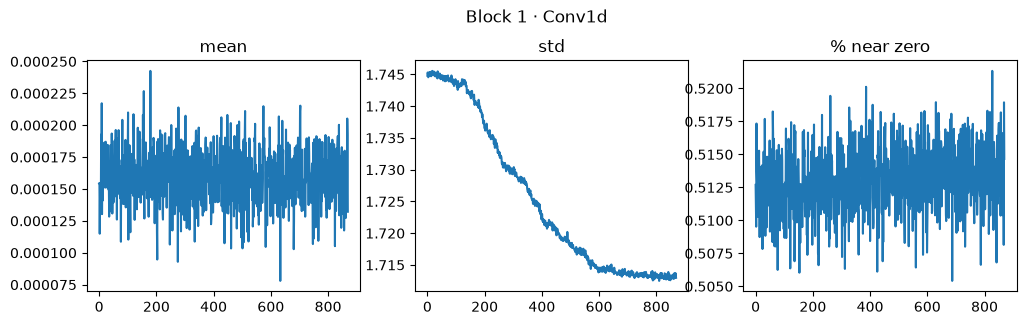

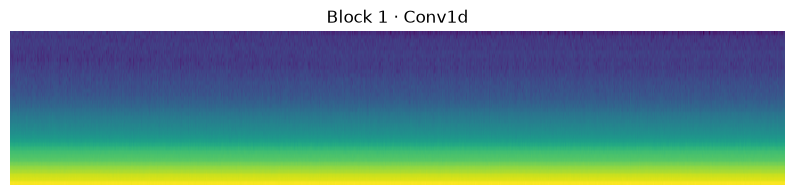

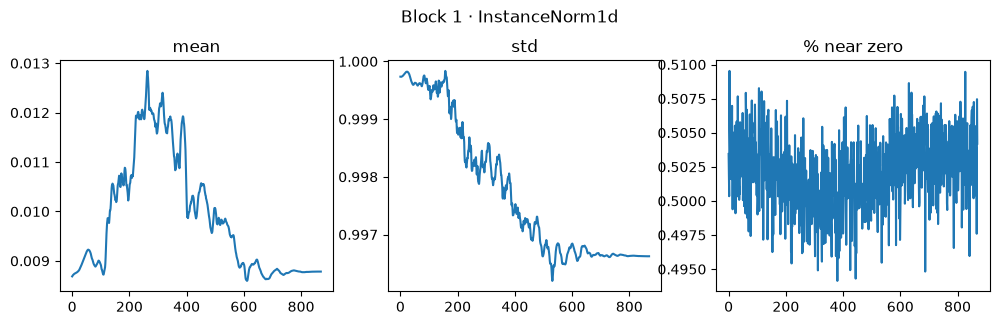

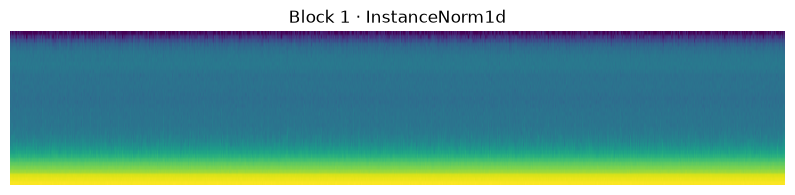

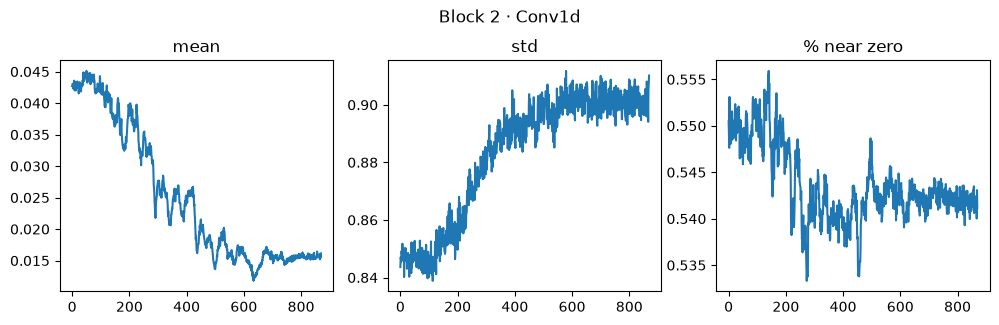

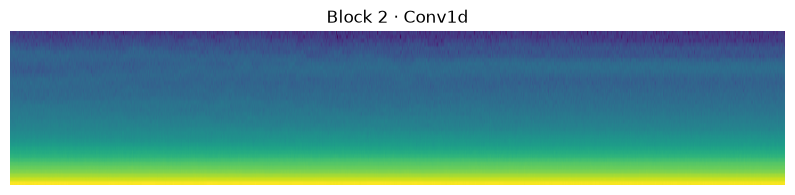

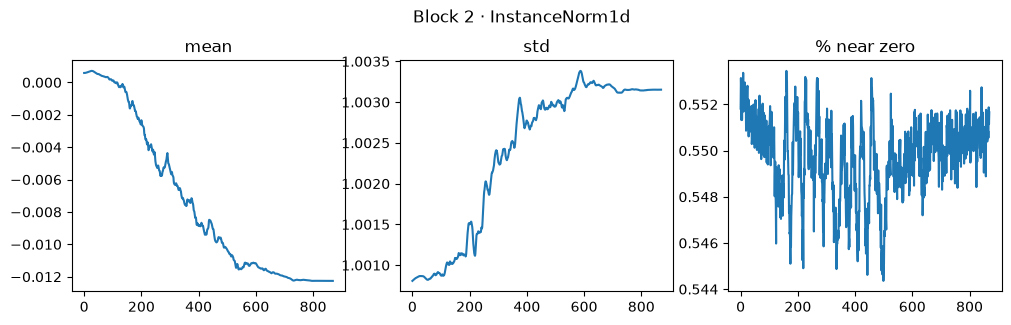

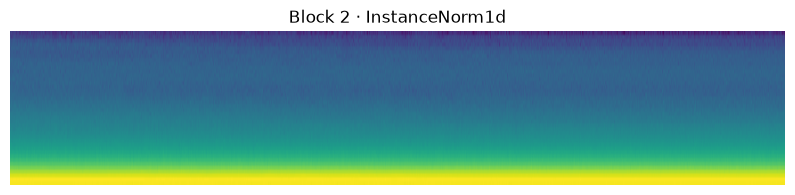

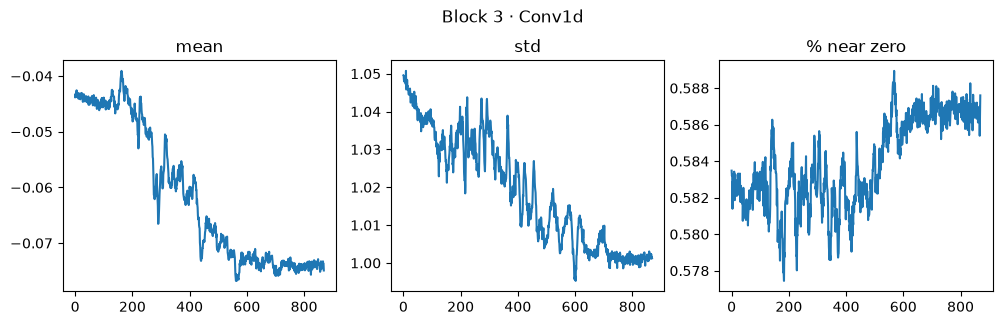

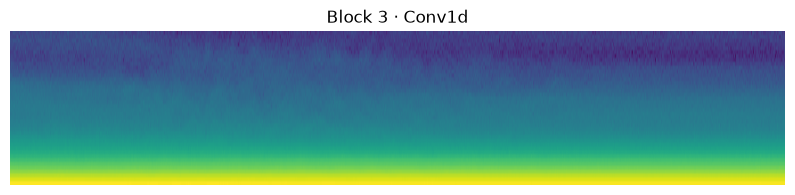

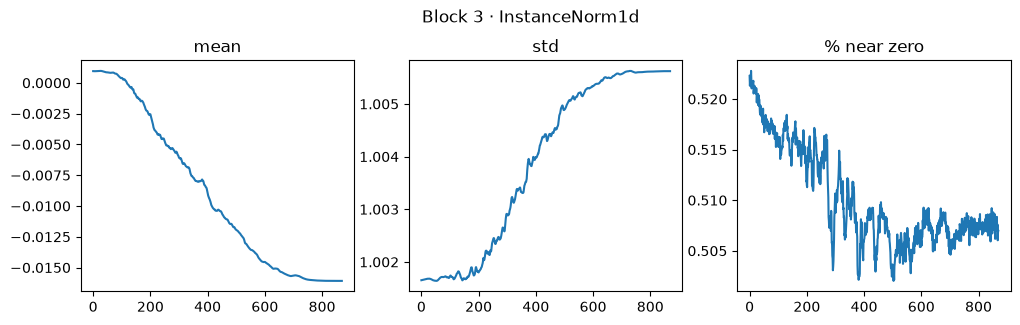

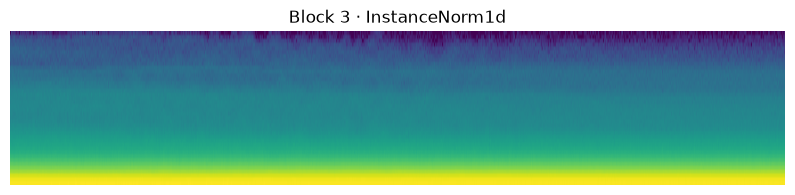

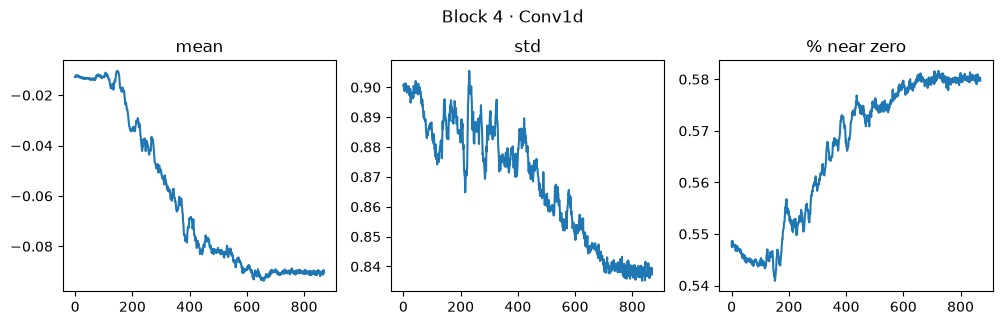

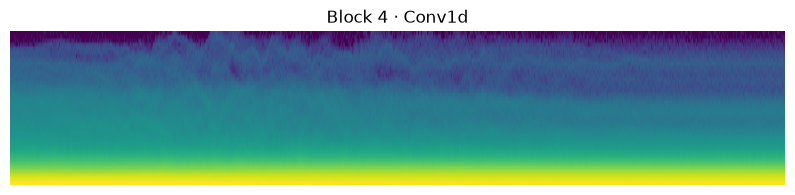

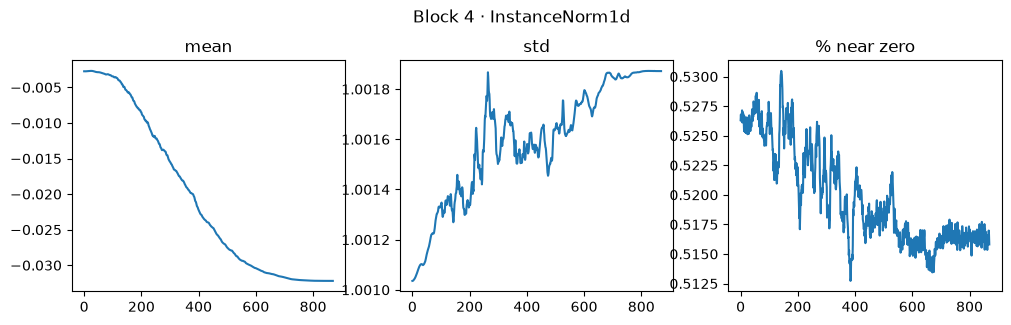

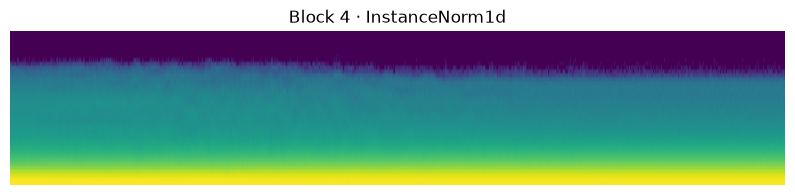

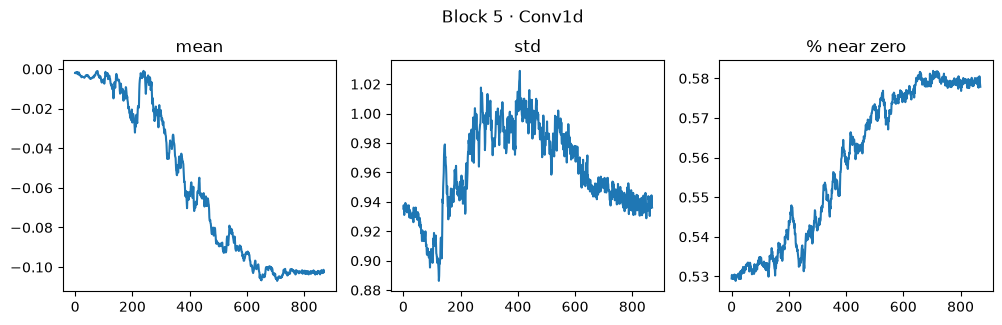

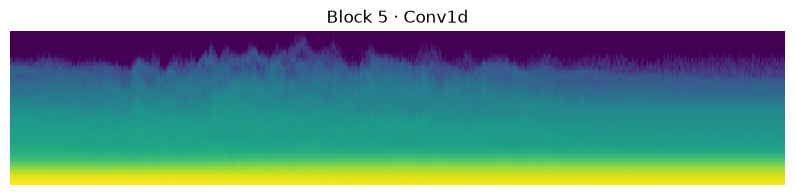

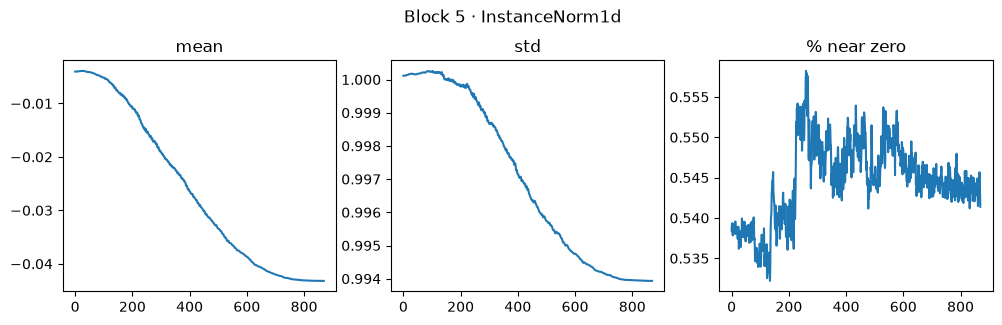

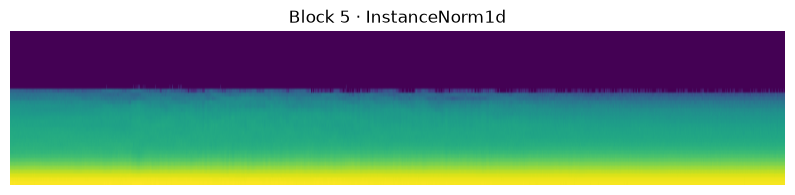

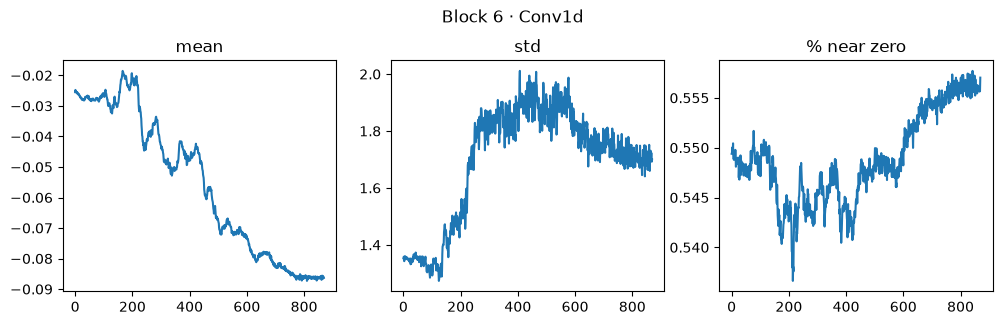

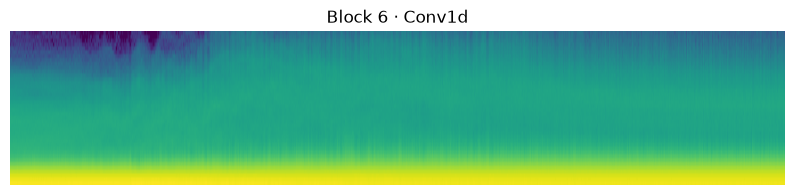

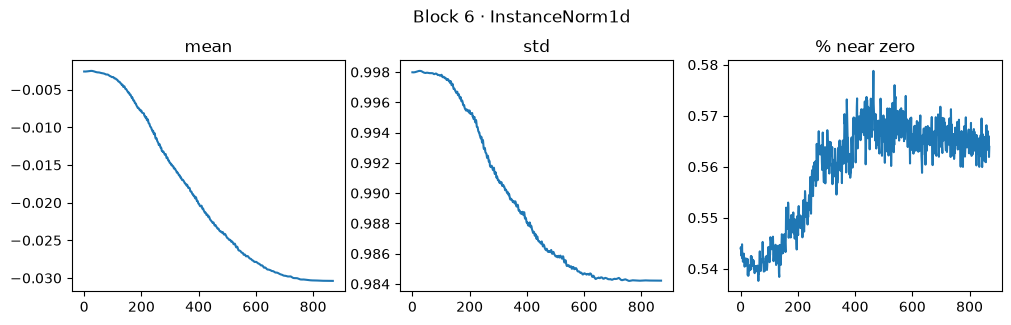

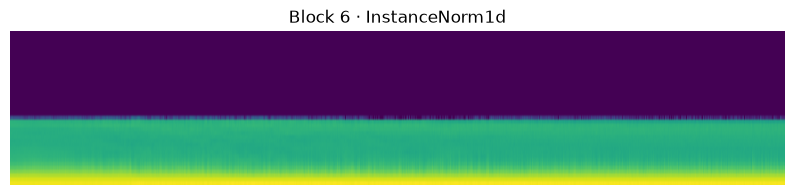

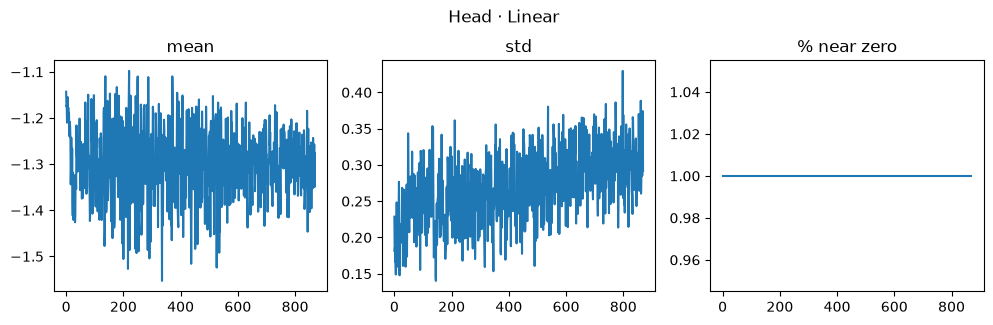

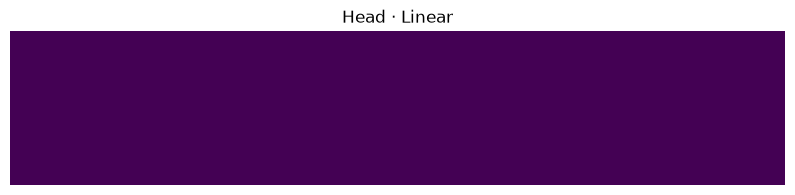

In [ ]:
names = layer_names(act_stats.modules)
for idx in range(len(act_stats.modules)):
    act_stats.plot_layer_stats(idx)
    plt.suptitle(names[idx], y=1.05)
    fig, ax = plt.subplots(figsize=(10, 2))
    act_stats.color_dim(idx, ax=ax)
    ax.set_aspect('auto')
    ax.set_title(names[idx])

(0.0, 0.2)

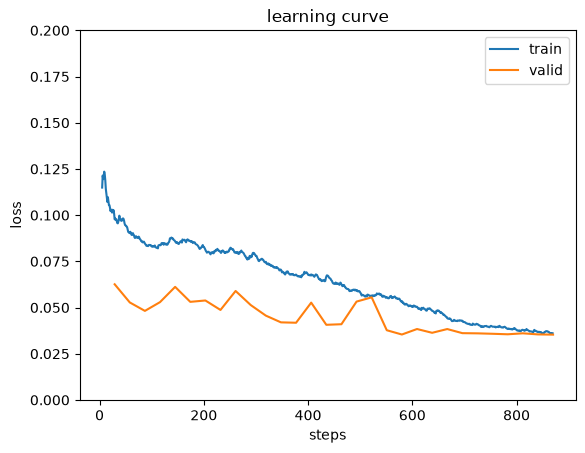

In [ ]:
ax = learn.recorder.plot_loss()
ax.set_ylim(0, 0.2)

In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(40, lr_max=2e-3)

/Users/franckalbinet/pro/dev/soilspecdl/.venv/lib/python3.12/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch,train_loss,valid_loss,r2_score,time
0,0.721967,0.154657,-0.213608,00:00
1,0.364854,0.120133,0.057307,00:00
2,0.247662,0.111158,0.127734,00:00
3,0.191712,0.098838,0.224410,00:00
4,0.161257,0.120044,0.058005,00:00
5,0.140051,0.071302,0.440484,00:00
6,0.127276,0.074739,0.413515,00:00
7,0.114667,0.063567,0.501180,00:00
8,0.103120,0.050984,0.599925,00:00
9,0.099450,0.055239,0.566531,00:00


(0.0, 0.2)

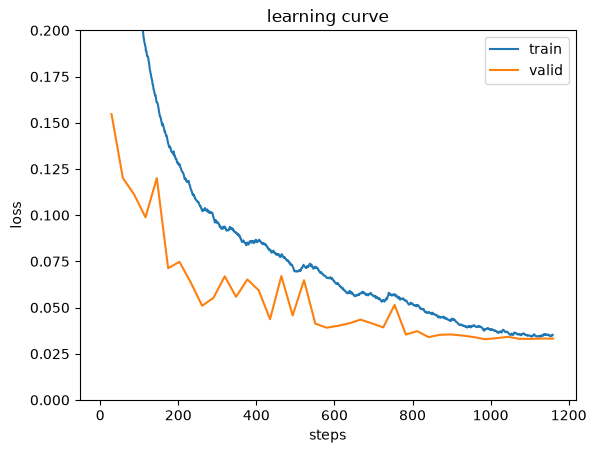

In [ ]:
ax = learn.recorder.plot_loss()
ax.set_ylim(0, 0.2)

In [ ]:
from sklearn.model_selection import KFold
from soilspecdl.dataloader import TensorSpectrum, SpectralBlock
from soilspecdl.transforms import StandardizeSpectrum
import numpy as np

def get_kfold_dls(X, y, wns, train_idx, valid_idx, bs=32):
    TensorSpectrum.wns = wns
    items = list(range(len(X)))
    def _ds_splitter(o): return list(train_idx), list(valid_idx)
    dblock = DataBlock(blocks=(SpectralBlock(), RegressionBlock()), splitter=_ds_splitter,
        get_x=lambda i: X[i], get_y=lambda i: y[i], batch_tfms=[StandardizeSpectrum()])
    return dblock.dataloaders(items, bs=bs)

X_train, y_train, wns = data_fuku['train']['X'], data_fuku['train']['y'], data_fuku['wns']

# Select n_epochs via CV instead of eyeballing one valid curve. Each candidate
# runs the FULL one-cycle schedule per fold -- no early stopping mid-schedule,
# since that grabs weights before the LR has annealed and defeats the point
# of one-cycle.
epoch_grid = [10, 15, 20, 25, 30, 40, 50, 60, 70, 80]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = {n: [] for n in epoch_grid}
for n_epochs in epoch_grid:
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_train)):
        dls = get_kfold_dls(X_train, y_train, wns, train_idx, valid_idx)
        learn = Learner(dls, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score())
        with learn.no_bar(), learn.no_logging():
            learn.fit_one_cycle(n_epochs, lr_max=2e-3)
        _, r2 = learn.validate()
        cv_r2[n_epochs].append(r2)
    r2s = np.array(cv_r2[n_epochs])
    print(f"epochs={n_epochs:>3}: r2 = {r2s.mean():.4f} ± {r2s.std():.4f}")

# With only 5 folds over ~1,194 samples, a bare argmax over these means would
# just be fitting epoch count to CV noise -- the failure mode CV is meant to
# avoid. Instead, take the smallest epoch count whose mean r2 is within one
# std (of the best candidate) of the best mean: cheaper, and not chasing a
# difference the CV can't actually resolve.
means = {n: np.mean(cv_r2[n]) for n in epoch_grid}
best_n = max(means, key=means.get)
threshold = means[best_n] - np.std(cv_r2[best_n])
best_epochs = min(n for n in epoch_grid if means[n] >= threshold)
print(f"\nbest epoch budget: {best_epochs}")

epochs= 10: r2 = 0.5080 ± 0.0838


epochs= 15: r2 = 0.5583 ± 0.0614


epochs= 20: r2 = 0.5823 ± 0.0681


epochs= 25: r2 = 0.5994 ± 0.0649


epochs= 30: r2 = 0.6075 ± 0.0622


epochs= 40: r2 = 0.6245 ± 0.0493


epochs= 50: r2 = 0.6409 ± 0.0401


epochs= 60: r2 = 0.6388 ± 0.0554


epochs= 70: r2 = 0.6336 ± 0.0436


epochs= 80: r2 = 0.6353 ± 0.0429

best epoch budget: 30


In [ ]:
# Final model: train on (nearly) the full train set -- epoch count was
# already selected via CV, so there's no more reason to hold back 20% just
# for a monitoring curve. Keep a token 2% holdout purely because fastai's
# Learner needs a non-empty valid_dl to run; it doesn't drive any decision.
# test_idx is unaffected by valid_pct (it's always np.arange(n_train, n)).
from sklearn.metrics import r2_score

full_dls, _ = get_spectral_dls(X_all, y_all, wns,
    splitter=get_pre_splitter(n_train=len(X_train), valid_pct=0.02),
    batch_tfms=[StandardizeSpectrum()])

final_learn = Learner(full_dls, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score())
#final_learn.fit_one_cycle(best_epochs, lr_max=2e-3)
final_learn.fit_one_cycle(50, lr_max=2e-3)

test_dl = full_dls.test_dl(test_idx.tolist())
preds, _ = final_learn.get_preds(dl=test_dl)
print(f"held-out test r2: {r2_score(y_all[test_idx], preds.numpy()):.4f}")

epoch,train_loss,valid_loss,r2_score,time


held-out test r2: 0.6281


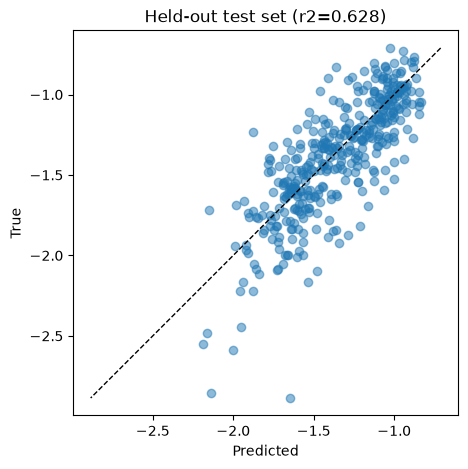

In [ ]:
y_true = y_all[test_idx]
y_pred = preds.numpy().squeeze()

fig, ax = plt.subplots(figsize=(5, 5))
#ax.scatter(y_true, y_pred, alpha=0.5)
ax.scatter(y_pred, y_true, alpha=0.5)
#lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
lims = [max(y_true.max(), y_pred.max()), min(y_true.min(), y_pred.min())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f"Held-out test set (r2={r2_score(y_true, y_pred):.3f})")
ax.set_aspect('equal')